# Split-Chain oPool Library Design

Design 4 combinatorial oPool libraries (alpha/beta × DRG/GIG) for shuffled chain pairing.

## Design principle

Each oligo varies **all enriched positions simultaneously**. The IUPAC codon at each
position is chosen from the top-K desired AAs so that
`product(n_aas_encoded_per_pos) ≈ target_diversity`.

For ~10 positions and target ~1000: **K=2 desired AAs per position** gives
`2^10 = 1024` sequences per main combo oligo.  Every TCR drawn from that
oligo carries mutations at several positions at once — not just 1–3.

## Oligo phases
| Phase | Count | Description |
|-------|-------|-------------|
| WT | 1 | Reference wildtype |
| main_combo | 1 | All positions, top-2 AAs → tight codons, diversity ≈ target |
| single_pos | n_pos | One position varied alone, all others WT — marginal-effect baseline |
| combo_k3 | budget | All positions, top-3 AAs per pos — broader exploration |

**Enrichment metric:** `enrich_pos1x_vs_neg`; GIG02 uses `enrich_pos2x_vs_neg`.
**Synergy:** E = observed_log2fc_dev − (marginal_α + marginal_β).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from itertools import product
import warnings
warnings.filterwarnings('ignore')

NB_DIR   = Path('/cluster/project/reddy/marluca/NGS_pipeline/notebooks')
DATA_DIR = Path('/cluster/project/reddy/marluca/NGS_pipeline/data/P3620_LUCA-TCRDMF5-abDMS/04_variant_labeling')
OUT_DIR  = NB_DIR / 'opool_designs'
OUT_DIR.mkdir(exist_ok=True)
print(f'Output: {OUT_DIR}')

Output: /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs


In [16]:
PEPTIDES = ['DRG01','DRG02','DRG03','DRG04','GIG01','GIG02','GIG03','GIG04','GIG05']
DRG_PEPS = [p for p in PEPTIDES if p.startswith('DRG')]
GIG_PEPS = [p for p in PEPTIDES if p.startswith('GIG')]

WT_ALPHA  = 'AVNFGGGKLI'
WT_BETA   = 'ASSLSFGTEAF'
ALPHA_LEN = len(WT_ALPHA)
BETA_LEN  = len(WT_BETA)

ENRICHMENT_COL = {p: 'enrich_pos1x_vs_neg' for p in PEPTIDES}
ENRICHMENT_COL['GIG02'] = 'enrich_pos2x_vs_neg'
PSEUDOCOUNT = 1e-3

# ── Design parameters ────────────────────────────────────────────────────
TARGET_ALPHA_DIV  = 800    # target unique alpha sequences per pool
TARGET_BETA_DIV   = 1250   # target unique beta sequences per pool
MIN_SCORE         = 0.2    # min composite score to include a position
K_MAX             = 8      # max desired AAs for broad codon search (single-pos QC)
K_MAIN            = 2      # max desired AAs per position for the canonical codon
SYN_WEIGHT        = 0.5

# Codon scoring
STOP_PENALTY      = 10.0
EXTRA_PENALTY     = 0.3    # per bystander AA
MIN_EFF           = 0.5    # efficiency threshold for canonical codons
EFFICIENCY_THRESH = 0.3    # QC flag threshold

print(f'Alpha WT: {WT_ALPHA}  ({ALPHA_LEN} aa)')
print(f'Beta  WT: {WT_BETA}  ({BETA_LEN} aa)')


Alpha WT: AVNFGGGKLI  (10 aa)
Beta  WT: ASSLSFGTEAF  (11 aa)


## Genetic Code and IUPAC Utilities

In [17]:
GENETIC_CODE = {
    'ATA':'I','ATC':'I','ATT':'I','ATG':'M',
    'ACA':'T','ACC':'T','ACG':'T','ACT':'T',
    'AAC':'N','AAT':'N','AAA':'K','AAG':'K',
    'AGC':'S','AGT':'S','AGA':'R','AGG':'R',
    'CTA':'L','CTC':'L','CTG':'L','CTT':'L',
    'CCA':'P','CCC':'P','CCG':'P','CCT':'P',
    'CAC':'H','CAT':'H','CAA':'Q','CAG':'Q',
    'CGA':'R','CGC':'R','CGG':'R','CGT':'R',
    'GTA':'V','GTC':'V','GTG':'V','GTT':'V',
    'GCA':'A','GCC':'A','GCG':'A','GCT':'A',
    'GAC':'D','GAT':'D','GAA':'E','GAG':'E',
    'GGA':'G','GGC':'G','GGG':'G','GGT':'G',
    'TCA':'S','TCC':'S','TCG':'S','TCT':'S',
    'TTC':'F','TTT':'F','TTA':'L','TTG':'L',
    'TAC':'Y','TAT':'Y','TAA':'*','TAG':'*',
    'TGC':'C','TGT':'C','TGA':'*','TGG':'W',
}
IUPAC_BASES = {
    'A':{'A'},'C':{'C'},'G':{'G'},'T':{'T'},
    'R':{'A','G'},'Y':{'C','T'},'S':{'G','C'},'W':{'A','T'},
    'K':{'G','T'},'M':{'A','C'},
    'B':{'C','G','T'},'D':{'A','G','T'},'H':{'A','C','T'},'V':{'A','C','G'},
    'N':{'A','C','G','T'},
}

def decode_iupac(triplet):
    codons = [b1+b2+b3 for b1 in IUPAC_BASES[triplet[0]]
                        for b2 in IUPAC_BASES[triplet[1]]
                        for b3 in IUPAC_BASES[triplet[2]]]
    aas, stops = set(), 0
    for c in codons:
        aa = GENETIC_CODE.get(c,'?')
        if aa == '*': stops += 1
        else: aas.add(aa)
    return aas, stops/len(codons)

ALL_IUPAC = list(IUPAC_BASES.keys())
IUPAC_PROPS = {}
for _t in product(ALL_IUPAC, repeat=3):
    _triplet = ''.join(_t)
    _aas, _sf = decode_iupac(_triplet)
    if _aas:
        IUPAC_PROPS[_triplet] = {'aas': frozenset(_aas), 'stop_frac': _sf}

print(f'Pre-computed {len(IUPAC_PROPS)} valid IUPAC triplets')

Pre-computed 3370 valid IUPAC triplets


## Load Enrichment Data

In [18]:
def load_single_effects(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        rows = []
        for _, r in df.iterrows():
            v = r['log2e_dev']
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq != WT_ALPHA:
                for pos in range(ALPHA_LEN):
                    if aseq[pos] != WT_ALPHA[pos]:
                        rows.append(('alpha', pos, aseq[pos], v)); break
            if bseq != WT_BETA:
                for pos in range(BETA_LEN):
                    if bseq[pos] != WT_BETA[pos]:
                        rows.append(('beta', pos, bseq[pos], v)); break
        fx = (pd.DataFrame(rows, columns=['chain','position','aa','log2e_dev'])
              .groupby(['chain','position','aa'])['log2e_dev']
              .agg(log2fc='mean', n_variants='count').reset_index())
        result[pep] = fx
    return result

print('Loading...')
SINGLE_FX = load_single_effects(PEPTIDES)
print(f'Done. DRG01: {len(SINGLE_FX["DRG01"])} entries')
SINGLE_FX['DRG01'].head(6)

Loading...
Done. DRG01: 399 entries


,chain,position,aa,log2fc,n_variants
0,alpha,0,C,0.117227,100
1,alpha,0,D,0.072407,73
2,alpha,0,E,-0.145926,106
3,alpha,0,F,0.188084,123
4,alpha,0,G,3.041486,175
5,alpha,0,H,0.565789,87


## Compute Epistasis (Synergy)

In [19]:
def compute_epistasis(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        fx = SINGLE_FX[pep].set_index(['chain','position','aa'])['log2fc'].to_dict()
        rows = []
        for _, r in df.iterrows():
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq == WT_ALPHA or bseq == WT_BETA: continue
            apos = aaa = bpos = baa = None
            for pos in range(ALPHA_LEN):
                if aseq[pos] != WT_ALPHA[pos]: apos, aaa = pos, aseq[pos]; break
            for pos in range(BETA_LEN):
                if bseq[pos] != WT_BETA[pos]: bpos, baa = pos, bseq[pos]; break
            if apos is None or bpos is None: continue
            ma = fx.get(('alpha', apos, aaa), 0.0)
            mb = fx.get(('beta',  bpos, baa), 0.0)
            obs = r['log2e_dev']
            rows.append({'alpha_pos': apos, 'aa_alpha': aaa,
                         'beta_pos':  bpos, 'aa_beta':  baa,
                         'log2fc_obs': obs, 'log2fc_exp': ma+mb,
                         'epistasis': obs - (ma+mb)})
        result[pep] = pd.DataFrame(rows)
    return result

print('Computing epistasis...')
EPISTASIS = compute_epistasis(PEPTIDES)
print(f'Done. DRG01: {len(EPISTASIS["DRG01"])} pairs')
EPISTASIS['DRG01'].head(6)

Computing epistasis...
Done. DRG01: 30317 pairs


,alpha_pos,aa_alpha,beta_pos,aa_beta,log2fc_obs,log2fc_exp,epistasis
0,1,A,1,A,2.289790,2.896811,-0.607021
1,1,C,1,A,4.988507,1.362625,3.625882
2,1,E,1,A,-2.625310,-0.788783,-1.836527
3,1,F,1,A,-2.625310,-0.435898,-2.189412
4,1,G,1,A,-4.270127,-0.198898,-4.071229
5,1,H,1,A,-3.451897,-0.658752,-2.793145


## Pool Enrichment and Composite Scores

In [8]:
def synergy_bonus_for_chain(pep_list, chain, min_epi=0.2):
    all_epi = pd.concat([EPISTASIS[p] for p in pep_list if not EPISTASIS[p].empty], ignore_index=True)
    if chain == 'alpha': pos_col, aa_col, opos_col = 'alpha_pos','aa_alpha','beta_pos'
    else:                pos_col, aa_col, opos_col = 'beta_pos', 'aa_beta', 'alpha_pos'
    pooled = all_epi.groupby([pos_col, aa_col, opos_col])['epistasis'].mean().reset_index()
    syn = defaultdict(float)
    for _, row in pooled.iterrows():
        if row['epistasis'] > min_epi:
            syn[(int(row[pos_col]), row[aa_col])] += row['epistasis']
    return dict(syn)


def pool_composite_scores(pep_list, chain):
    chain_dfs = [SINGLE_FX[p][SINGLE_FX[p]['chain']==chain] for p in pep_list if p in SINGLE_FX]
    pooled = (pd.concat(chain_dfs, ignore_index=True)
              .groupby(['position','aa'])['log2fc'].mean().reset_index()
              .rename(columns={'log2fc':'base_score'}))
    syn_raw = synergy_bonus_for_chain(pep_list, chain)
    pooled['synergy_bonus'] = pooled.apply(lambda r: syn_raw.get((int(r['position']), r['aa']), 0.0), axis=1)
    for pos, grp in pooled.groupby('position'):
        mx = grp['synergy_bonus'].max()
        if mx > 0: pooled.loc[pooled['position']==pos,'synergy_bonus'] /= mx
    pooled['composite'] = pooled['base_score'] + SYN_WEIGHT * pooled['synergy_bonus']
    return pooled.sort_values(['position','composite'], ascending=[True,False])


print('Alpha-DRG composite scores (top 12):')
print(pool_composite_scores(DRG_PEPS,'alpha').nlargest(12,'composite').to_string(index=False))

Alpha-DRG composite scores (top 12):
 position aa  base_score  synergy_bonus  composite
        1  A    1.482588       1.000000   1.982588
        7  M    1.594477       0.744955   1.966954
        3  M    1.429843       1.000000   1.929843
        9  L    1.433713       0.991767   1.929596
        9  Q    1.367265       0.953385   1.843958
        0  G    1.445018       0.641664   1.765850
        7  F    1.342001       0.737770   1.710886
        7  Y    1.200817       1.000000   1.700817
        1  C    1.217594       0.823245   1.629217
        7  L    1.096698       0.978758   1.586077
        0  P    1.029176       0.949839   1.504096
        9  M    0.986987       0.962146   1.468059


## Codon-First Scoring

In [9]:
def find_best_iupac_codon(desired_aas, aa_scores):
    """
    Enumerate all IUPAC triplets; return the one maximising:
        sum(composite[aa] for aa in desired & encoded)
        - EXTRA_PENALTY * |encoded - desired|
        - STOP_PENALTY  * stop_frac
    Ties in score are broken in favour of the codon with higher efficiency
    (fewer bystanders), so tight codons are always preferred when equivalent.
    """
    best_score, best_triplet, best_encoded, best_eff = -np.inf, None, frozenset(), 0.0

    for triplet, props in IUPAC_PROPS.items():
        encoded = props['aas']
        covered = desired_aas & encoded
        if not covered:
            continue
        score = (sum(aa_scores.get(aa, 0.0) for aa in covered)
                 - EXTRA_PENALTY * len(encoded - desired_aas)
                 - STOP_PENALTY  * props['stop_frac'])
        eff = len(covered) / max(len(encoded), 1)
        # prefer higher score; break ties by higher efficiency (tighter codon)
        if score > best_score or (score == best_score and eff > best_eff):
            best_score   = score
            best_triplet = triplet
            best_encoded = encoded
            best_eff     = eff

    return best_triplet, frozenset(best_encoded), best_eff


# Sanity checks
for _aas in [{'V','A'}, {'K','R'}, {'F','Y'}, {'L','I','M'}, {'M','F'}, {'A','S','T'}]:
    _s = {aa: 1.0 for aa in _aas}
    _t, _enc, _eff = find_best_iupac_codon(_aas, _s)
    print(f'desired {sorted(_aas)} -> {_t}  encodes {sorted(_enc)}  n={len(_enc)}  eff={_eff:.2f}')


desired ['A', 'V'] -> GYA  encodes ['A', 'V']  n=2  eff=1.00
desired ['K', 'R'] -> ARA  encodes ['K', 'R']  n=2  eff=1.00
desired ['F', 'Y'] -> TWC  encodes ['F', 'Y']  n=2  eff=1.00
desired ['I', 'L', 'M'] -> WTR  encodes ['I', 'L', 'M']  n=3  eff=1.00
desired ['F', 'M'] -> WTS  encodes ['F', 'I', 'L', 'M']  n=4  eff=0.50
desired ['A', 'S', 'T'] -> DCA  encodes ['A', 'S', 'T']  n=3  eff=1.00


## Tiered-Position oPool Design

**Strategy:** positions are assigned to three tiers.
Different oligos vary *different subsets* of positions — not the same
set with different codon widths.

- **Tier 1 (backbone):** top-ranked positions by composite score; always varied.
- **Tier 2 (extensions):** each added one at a time on top of Tier 1.
- **Tier 3 (fixed):** fixed at single best enriched AA; no diversity contribution.

Total diversity ≈ target_diversity for each chain pool.


In [10]:
def _wt_triplets(wt_seq):
    t = {}
    for pos, aa in enumerate(wt_seq):
        for codon, enc_aa in GENETIC_CODE.items():
            if enc_aa == aa: t[pos] = codon; break
    return t


def _make_oligo(oligo_id, oligo_type, positions_encoded, wt_seq, wt_tri):
    """Build one oligo.  positions_encoded: pos -> (triplet, frozenset_aas, eff)"""
    chain_len = len(wt_seq)
    pos_aas   = {p: frozenset({wt_seq[p]}) for p in range(chain_len)}
    iupac_t   = dict(wt_tri)
    effs      = {}
    diversity = 1
    for pos, (triplet, encoded, eff) in positions_encoded.items():
        pos_aas[pos] = encoded
        iupac_t[pos] = triplet
        effs[pos]    = eff
        diversity   *= len(encoded)
    return {
        'oligo_id':         oligo_id,
        'oligo_type':       oligo_type,
        'position_aas':     pos_aas,
        'iupac_triplets':   iupac_t,
        'diversity':        diversity,
        'codon_efficiency': effs,
        'is_leaky':         any(e < EFFICIENCY_THRESH for e in effs.values()),
        'n_varied':         len(positions_encoded),
    }


def _best_single_codon(pos, cands_by_pos, wt_tri):
    """Single best-AA codon for a fixed (non-varied) position."""
    if pos not in cands_by_pos or not cands_by_pos[pos]:
        return None
    top_aa, top_sc = cands_by_pos[pos][0]
    t, enc, eff = find_best_iupac_codon({top_aa}, {top_aa: top_sc})
    return (t, enc, eff)


def _canonical_codon(pos, cands_by_pos):
    """Greedy canonical codon for a varied position: top-K_MAIN AAs, eff >= MIN_EFF."""
    cands = cands_by_pos[pos]
    best_triplet, best_encoded, best_eff = None, frozenset(), 0.0

    for k in range(1, min(len(cands) + 1, K_MAIN + 1)):
        desired_k   = {aa for aa, _ in cands[:k]}
        aa_scores_k = {aa: sc for aa, sc in cands[:k]}
        triplet, encoded, eff = find_best_iupac_codon(desired_k, aa_scores_k)
        if triplet is None:
            break
        if not desired_k.issubset(encoded):
            break   # can't cover all desired AAs — stop
        if eff >= MIN_EFF:
            best_triplet, best_encoded, best_eff = triplet, encoded, eff
        else:
            break
    return best_triplet, best_encoded, best_eff


def _oligo_dna(oligo, chain_len):
    return ''.join(oligo['iupac_triplets'][p] for p in range(chain_len))


def design_pool(chain, pep_list, wt_seq, target_diversity):
    """
    Tiered-position combinatorial oPool design.

    Assigns enriched positions to three tiers:
      Tier 1 (backbone): always vary in every non-WT oligo.
              Chosen so that product(canonical_div) stays below target/3,
              leaving budget for Tier 2 extensions.
      Tier 2 (extensions): each position gets its own oligo that adds it
              on top of the Tier 1 backbone. Together these oligos fill the
              target diversity.
      Tier 3 (fixed): fixed at single best enriched AA in all oligos —
              never varied, contributes no diversity.

    Diversity = sum over oligos of product(encoded_aas at varied positions).
    Different oligos vary DIFFERENT subsets of positions.
    """
    chain_len = len(wt_seq)
    wt_tri    = _wt_triplets(wt_seq)
    scores_df = pool_composite_scores(pep_list, chain)

    # Collect enriched positions sorted by max composite score (best first)
    cands_by_pos = {}
    for pos, grp in scores_df.groupby('position'):
        top = (grp[grp['composite'] >= MIN_SCORE]
               .nlargest(K_MAX, 'composite')[['aa','composite']].values.tolist())
        if top:
            cands_by_pos[int(pos)] = top

    sorted_pos = sorted(cands_by_pos,
                        key=lambda p: max(sc for _, sc in cands_by_pos[p]),
                        reverse=True)
    n_pos = len(sorted_pos)

    # Pre-compute canonical codon and single-best codon for every enriched position
    canon   = {}   # pos -> (triplet, frozenset, eff)  — used when position varies
    fixed_c = {}   # pos -> (triplet, frozenset, eff)  — used when position is fixed
    for pos in sorted_pos:
        t, enc, eff = _canonical_codon(pos, cands_by_pos)
        if t is not None:
            canon[pos] = (t, enc, eff)
        t1, enc1, eff1 = _best_single_codon(pos, cands_by_pos, wt_tri)
        if t1 is not None:
            fixed_c[pos] = (t1, enc1, eff1)

    # ── Tier assignment (auto-calibrate to target_diversity) ──────────────
    tier1, tier2, tier3 = [], [], []
    tier1_div = 1

    # Grow Tier 1 until product would exceed target / 3
    # Cap at (n_pos - 2) so at least 2 positions remain for Tier 2 extensions
    tier1_cap = max(1, n_pos - 2)
    for pos in sorted_pos:
        if pos not in canon:
            tier3.append(pos)
            continue
        proposed = tier1_div * len(canon[pos][1])
        if proposed > target_diversity // 3 or len(tier1) >= tier1_cap:
            break
        tier1_div = proposed
        tier1.append(pos)

    remaining = [p for p in sorted_pos if p not in tier1]

    # Add Tier 2 positions greedily until diversity budget is spent
    ext_budget = target_diversity - tier1_div
    for pos in remaining:
        if pos not in canon:
            tier3.append(pos)
            continue
        ext_div = tier1_div * len(canon[pos][1])
        tier2.append(pos)
        ext_budget -= ext_div
        if ext_budget <= 0:
            break

    # Any remaining positions go to Tier 3
    in_t1t2 = set(tier1 + tier2)
    tier3 += [p for p in sorted_pos if p not in in_t1t2 and p not in tier3]

    total_div = tier1_div + sum(tier1_div * len(canon[p][1]) for p in tier2 if p in canon)

    print(f'  {chain}: {n_pos} enriched positions')
    print(f'  Tier 1 ({len(tier1)} pos): {tier1} — backbone div = {tier1_div}')
    print(f'  Tier 2 ({len(tier2)} pos): {tier2}')
    print(f'  Tier 3 ({len(tier3)} pos): {tier3} — fixed at best AA')
    print(f'  Estimated total diversity: {total_div:,}  (target {target_diversity:,})')

    seen_dna = set()
    oligos   = []

    def add(oligo):
        dna = _oligo_dna(oligo, chain_len)
        if dna not in seen_dna:
            seen_dna.add(dna)
            oligos.append(oligo)
            return True
        return False

    # ── Oligo 0: WT reference ─────────────────────────────────────────────
    wt_o = _make_oligo(f'{chain}_wt', 'WT', {}, wt_seq, wt_tri)
    wt_o['codon_efficiency'] = {p: 1.0 for p in range(chain_len)}
    wt_o['diversity'] = 1; wt_o['is_leaky'] = False
    add(wt_o)

    def _fixed_enc(varied_positions):
        """For positions not being varied, use single-best-AA codon (not WT)."""
        enc = {}
        for pos in sorted_pos:
            if pos in varied_positions:
                enc[pos] = canon[pos]
            elif pos in fixed_c:
                enc[pos] = fixed_c[pos]
            # (positions without any codon just stay at WT via wt_tri)
        return enc

    # ── Oligo 1: Tier 1 backbone (only Tier 1 positions vary) ────────────
    add(_make_oligo(f'{chain}_tier1_backbone', 'tier1_backbone',
                    _fixed_enc(set(tier1)),
                    wt_seq, wt_tri))

    # ── Oligos 2…: Tier 2 extensions (Tier 1 + one Tier 2 position) ──────
    for pos in tier2:
        if pos not in canon:
            continue
        varied = set(tier1) | {pos}
        add(_make_oligo(f'{chain}_ext_p{pos:02d}', 'tier2_ext',
                        _fixed_enc(varied),
                        wt_seq, wt_tri))

    if total_div < target_diversity * 0.7:
        print(f'  NOTE: diversity {total_div} is below 70% of target {target_diversity}. '
              f'Consider lowering MIN_SCORE to include more positions.')
    print(f'  Total unique oligos: {len(oligos)}')
    return oligos


print('Designing all 4 pools...')
POOLS = {
    'alpha_DRG': design_pool('alpha', DRG_PEPS, WT_ALPHA, TARGET_ALPHA_DIV),
    'alpha_GIG': design_pool('alpha', GIG_PEPS, WT_ALPHA, TARGET_ALPHA_DIV),
    'beta_DRG':  design_pool('beta',  DRG_PEPS, WT_BETA,  TARGET_BETA_DIV),
    'beta_GIG':  design_pool('beta',  GIG_PEPS, WT_BETA,  TARGET_BETA_DIV),
}


Designing all 4 pools...
  alpha: 10 enriched positions
  Tier 1 (4 pos): [1, 7, 3, 9] — backbone div = 128
  Tier 2 (2 pos): [0, 8]
  Tier 3 (4 pos): [6, 2, 5, 4] — fixed at best AA
  Estimated total diversity: 1,152  (target 800)
  Total unique oligos: 4
  alpha: 9 enriched positions
  Tier 1 (7 pos): [7, 3, 6, 8, 9, 1, 0] — backbone div = 256
  Tier 2 (2 pos): [2, 5]
  Tier 3 (0 pos): [] — fixed at best AA
  Estimated total diversity: 768  (target 800)
  Total unique oligos: 2
  beta: 11 enriched positions
  Tier 1 (5 pos): [4, 8, 7, 10, 3] — backbone div = 256
  Tier 2 (1 pos): [2]
  Tier 3 (5 pos): [0, 1, 9, 6, 5] — fixed at best AA
  Estimated total diversity: 1,280  (target 1,250)
  Total unique oligos: 3
  beta: 9 enriched positions
  Tier 1 (5 pos): [8, 2, 7, 3, 10] — backbone div = 128
  Tier 2 (3 pos): [4, 0, 1]
  Tier 3 (1 pos): [9] — fixed at best AA
  Estimated total diversity: 1,664  (target 1,250)
  Total unique oligos: 5


## Diversity Check

In [11]:
print(f'{"Pool":<15} {"n_oligos":>9} {"tier1_div":>11} {"total_div":>11} {"target":>8}')
print('-' * 58)
for name, pool in POOLS.items():
    tgt = TARGET_ALPHA_DIV if 'alpha' in name else TARGET_BETA_DIV
    tier1 = next((o for o in pool if o['oligo_type'] == 'tier1_backbone'), None)
    td = tier1['diversity'] if tier1 else '-'
    total_div = sum(o['diversity'] for o in pool if o['oligo_type'] != 'WT')
    types = {}
    for o in pool: types[o['oligo_type']] = types.get(o['oligo_type'], 0) + 1
    print(f'{name:<15} {len(pool):>9} {td!s:>11} {total_div:>11,} {tgt:>8,}  {types}')

print()
for cls in ['DRG', 'GIG']:
    tgt = TARGET_ALPHA_DIV * TARGET_BETA_DIV
    ad = sum(o['diversity'] for o in POOLS[f'alpha_{cls}'] if o['oligo_type'] != 'WT')
    bd = sum(o['diversity'] for o in POOLS[f'beta_{cls}']  if o['oligo_type'] != 'WT')
    cross = ad * bd
    flag  = '  WARNING >10M!' if cross > 10_000_000 else '  OK'
    print(f'{cls}: {ad:,} alpha x {bd:,} beta = {cross:,.0f}{flag}')


Pool             n_oligos   tier1_div   total_div   target
----------------------------------------------------------
alpha_DRG               4         128       1,152      800  {'WT': 1, 'tier1_backbone': 1, 'tier2_ext': 2}
alpha_GIG               2         256         256      800  {'WT': 1, 'tier1_backbone': 1}
beta_DRG                3         256       1,280    1,250  {'WT': 1, 'tier1_backbone': 1, 'tier2_ext': 1}
beta_GIG                5         128       1,664    1,250  {'WT': 1, 'tier1_backbone': 1, 'tier2_ext': 3}

DRG: 1,152 alpha x 1,280 beta = 1,474,560  OK
GIG: 256 alpha x 1,664 beta = 425,984  OK


## Visualise: Which Positions Vary Per Oligo

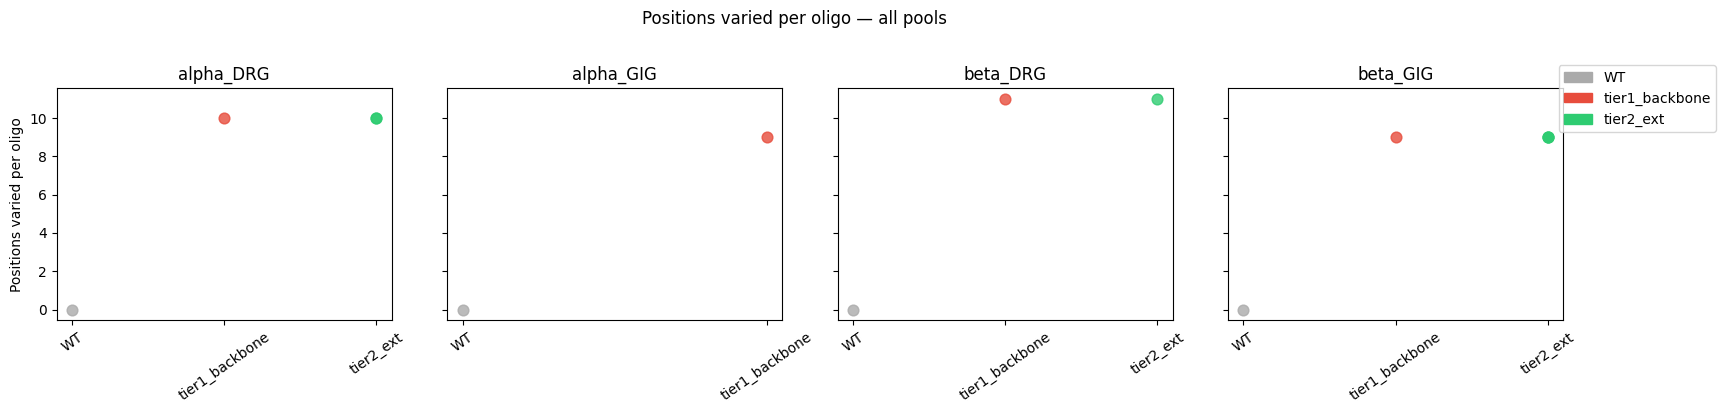

In [12]:
import matplotlib.patches as mpatches
colors = {'WT':'#aaa', 'tier1_backbone':'#e74c3c', 'tier2_ext':'#2ecc71'}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (name, pool) in zip(axes, POOLS.items()):
    for otype, col in colors.items():
        grp = [o['n_varied'] for o in pool if o['oligo_type'] == otype]
        if grp:
            ax.scatter([otype]*len(grp), grp, color=col, s=60, alpha=0.8, label=otype)
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=35)
axes[0].set_ylabel('Positions varied per oligo')
handles = [mpatches.Patch(color=c, label=t) for t, c in colors.items()]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.08, 0.9))
plt.suptitle('Positions varied per oligo — all pools', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'oligo_variability.pdf', bbox_inches='tight')
plt.show()


## Export to CSV

In [13]:
def pool_to_df(pool, chain, wt_seq):
    chain_len = len(wt_seq)
    rows, cumul = [], 0
    for o in pool:
        cumul += o['diversity']
        dna    = ''.join(o['iupac_triplets'][p] for p in range(chain_len))
        # Positions that actually provide choice (>1 encoded AA)
        varied = {p: sorted(aas)
                  for p, aas in o['position_aas'].items()
                  if len(aas) > 1}
        varied_str = '; '.join(f'p{p}:[{",".join(aas)}]' for p, aas in sorted(varied.items()))
        effs   = [e for e in o['codon_efficiency'].values() if e < 1.0]
        rows.append({
            'oligo_id':              o['oligo_id'],
            'oligo_type':            o['oligo_type'],
            'chain_dna':             dna,
            'dna_length':            len(dna),
            'n_variable_positions':  len(varied),  # positions with actual choice
            'variable_positions':    varied_str if varied_str else 'WT-only',
            'diversity':             o['diversity'],
            'cumulative_diversity':  cumul,
            'mean_codon_efficiency': round(np.mean(effs), 3) if effs else 1.0,
            'is_leaky':              o.get('is_leaky', False),
        })
    return pd.DataFrame(rows)


wt_seqs = {'alpha': WT_ALPHA, 'beta': WT_BETA}
for pool_name, pool in POOLS.items():
    chain = pool_name.split('_')[0]
    df    = pool_to_df(pool, chain, wt_seqs[chain])
    path  = OUT_DIR / f'opool_{pool_name}.csv'
    df.to_csv(path, index=False)
    print(f'Wrote {path}  ({len(df)} oligos)')
    display(df[['oligo_id','oligo_type','n_variable_positions','variable_positions','diversity']])


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_alpha_DRG.csv  (4 oligos)


,oligo_id,oligo_type,n_variable_positions,variable_positions,diversity
0,alpha_wt,WT,0,WT-only,1
1,alpha_tier1_backbone,tier1_backbone,4,"p1:[A,C,G,S]; p3:[K,L,M,Q]; p7:[F,I,L,M]; p9:[...",128
2,alpha_ext_p00,tier2_ext,5,"p0:[A,G,P,R]; p1:[A,C,G,S]; p3:[K,L,M,Q]; p7:[...",512
3,alpha_ext_p08,tier2_ext,5,"p1:[A,C,G,S]; p3:[K,L,M,Q]; p7:[F,I,L,M]; p8:[...",512


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_alpha_GIG.csv  (2 oligos)


,oligo_id,oligo_type,n_variable_positions,variable_positions,diversity
0,alpha_wt,WT,0,WT-only,1
1,alpha_tier1_backbone,tier1_backbone,6,"p0:[G,S]; p1:[A,C,G,S]; p6:[A,S]; p7:[F,Y]; p8...",256


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_beta_DRG.csv  (3 oligos)


,oligo_id,oligo_type,n_variable_positions,variable_positions,diversity
0,beta_wt,WT,0,WT-only,1
1,beta_tier1_backbone,tier1_backbone,5,"p3:[K,L,M,Q]; p4:[A,V]; p7:[K,M]; p8:[A,E,K,T]...",256
2,beta_ext_p02,tier2_ext,6,"p2:[A,D,H,P]; p3:[K,L,M,Q]; p4:[A,V]; p7:[K,M]...",1024


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_beta_GIG.csv  (5 oligos)


,oligo_id,oligo_type,n_variable_positions,variable_positions,diversity
0,beta_wt,WT,0,WT-only,1
1,beta_tier1_backbone,tier1_backbone,5,"p2:[A,G,P,R]; p3:[M,V]; p7:[G,I,S,V]; p8:[A,S]...",128
2,beta_ext_p04,tier2_ext,6,"p2:[A,G,P,R]; p3:[M,V]; p4:[A,M,T,V]; p7:[G,I,...",512
3,beta_ext_p00,tier2_ext,6,"p0:[D,G,N,S]; p2:[A,G,P,R]; p3:[M,V]; p7:[G,I,...",512
4,beta_ext_p01,tier2_ext,6,"p1:[A,E,K,T]; p2:[A,G,P,R]; p3:[M,V]; p7:[G,I,...",512


## QC: Codon Efficiency

In [14]:
for pool_name, pool in POOLS.items():
    effs  = [e for o in pool for e in o['codon_efficiency'].values() if e < 1.0]
    leaky = sum(1 for o in pool if o.get('is_leaky', False))
    if effs:
        print(f'{pool_name:<15}  mean_eff={np.mean(effs):.2f}  min_eff={np.min(effs):.2f}  leaky={leaky}/{len(pool)}')
    else:
        print(f'{pool_name:<15}  no variable positions')

alpha_DRG        mean_eff=0.50  min_eff=0.50  leaky=0/4
alpha_GIG        mean_eff=0.50  min_eff=0.50  leaky=0/2
beta_DRG         mean_eff=0.50  min_eff=0.50  leaky=0/3
beta_GIG         mean_eff=0.50  min_eff=0.50  leaky=0/5


In [ ]:

from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    import logomaker
    HAS_LOGOMAKER = True
except ImportError:
    HAS_LOGOMAKER = False
    print('logomaker not found; using scatter-grid fallback  (pip install logomaker for letter logos)')

# Chemistry colors: hydrophobic=orange, polar=green, basic=blue, acidic=red
AA_CHEM = {
    'A':'#e67e00','G':'#e67e00','V':'#e67e00','I':'#e67e00','L':'#e67e00',
    'M':'#e67e00','F':'#e67e00','W':'#e67e00','P':'#e67e00',
    'S':'#1e8c1e','T':'#1e8c1e','C':'#1e8c1e','Y':'#1e8c1e',
    'N':'#1e8c1e','Q':'#1e8c1e',
    'K':'#1a55cc','R':'#1a55cc','H':'#1a55cc',
    'D':'#cc1a1a','E':'#cc1a1a',
}
WT_COL = '#aaaaaa'


def _logo_matrix(pool, wt_seq):
    """Frequency matrix (pos × AA) summing to 1 per row.
    Unprobed positions carry the WT AA at frequency 1.0."""
    chain_len = len(wt_seq)
    design    = [o for o in pool if o['oligo_type'] != 'WT']

    pos_cnt = {p: Counter() for p in range(chain_len)}
    for o in design:
        for p, aas in o['position_aas'].items():
            for aa in aas:
                pos_cnt[p][aa] += 1

    all_aas = sorted(set(aa for c in pos_cnt.values() for aa in c) | set(wt_seq))

    rows = {}
    for p in range(chain_len):
        cnt   = pos_cnt[p]
        total = sum(cnt.values())
        if total == 0:
            rows[p] = {aa: (1.0 if aa == wt_seq[p] else 0.0) for aa in all_aas}
        else:
            rows[p] = {aa: cnt.get(aa, 0) / total for aa in all_aas}

    df = pd.DataFrame(rows).T.fillna(0.0)
    df.index = list(range(chain_len))
    df.index.name = 'pos'
    return df.loc[:, (df > 0).any(axis=0)]  # drop zero-only columns


def _probed_positions(pool, wt_seq):
    """Positions with any non-WT AA or multiple encoded AAs across design oligos."""
    design = [o for o in pool if o['oligo_type'] != 'WT']
    probed = set()
    for o in design:
        for p, aas in o['position_aas'].items():
            if len(aas) > 1 or (len(aas) == 1 and next(iter(aas)) != wt_seq[p]):
                probed.add(p)
    return probed


# ── Figure ──────────────────────────────────────────────────────────────────
n_pools = len(POOLS)
fig, axes = plt.subplots(n_pools, 1, figsize=(14, 4 * n_pools))
if n_pools == 1:
    axes = [axes]

fig.suptitle(
    'oPool Library — Sequence Logo\n'
    'grey = wildtype  |  colored = probed non-WT residues  |  shading = probed positions',
    fontsize=11, va='bottom'
)

for ax, (pool_name, pool) in zip(axes, POOLS.items()):
    wt_seq    = WT_ALPHA if 'alpha' in pool_name else WT_BETA
    chain_len = len(wt_seq)
    df        = _logo_matrix(pool, wt_seq)
    probed    = _probed_positions(pool, wt_seq)

    # Light background on probed columns
    for p in probed:
        ax.axvspan(p - 0.5, p + 0.5, color='#f5f0e8', zorder=0)

    if HAS_LOGOMAKER:
        logo = logomaker.Logo(
            df,
            ax=ax,
            color_scheme=AA_CHEM,
            show_spines=False,
            baseline_width=0,
            font_name='DejaVu Sans',
        )
        # Override WT residue glyphs to grey at every position
        for p in range(chain_len):
            wt_aa = wt_seq[p]
            if wt_aa in df.columns and df.loc[p, wt_aa] > 0:
                logo.style_single_glyph(p, wt_aa, color=WT_COL)
    else:
        # Fallback: bubble grid with letter labels
        all_aas = sorted(df.columns)
        aa_y    = {aa: i for i, aa in enumerate(all_aas)}
        for p in range(chain_len):
            for aa in df.columns:
                freq = df.loc[p, aa]
                if freq <= 0:
                    continue
                color = WT_COL if aa == wt_seq[p] else AA_CHEM.get(aa, '#555555')
                ax.scatter(p, aa_y[aa], s=max(50, freq * 450),
                           color=color, alpha=0.85, zorder=3)
                ax.text(p, aa_y[aa], aa, ha='center', va='center',
                        fontsize=8, fontweight='bold', color='white', zorder=4)
        ax.set_yticks(range(len(all_aas)))
        ax.set_yticklabels(all_aas, fontsize=8, fontfamily='monospace')
        ax.set_ylim(-0.7, len(all_aas) - 0.3)

    # x-axis: WT residue + position index (e.g. "A0", "V1")
    ax.set_xticks(range(chain_len))
    ax.set_xticklabels(
        [f'{wt_seq[i]}{i}' for i in range(chain_len)],
        fontsize=9, fontfamily='monospace',
    )
    ax.set_xlim(-0.6, chain_len - 0.4)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.set_title(pool_name, fontsize=11, fontweight='bold', loc='left', pad=4)
    ax.tick_params(axis='x', length=0, pad=4)

legend_handles = [
    mpatches.Patch(color='#e67e00', label='Hydrophobic (A,G,V,I,L,M,F,W,P)'),
    mpatches.Patch(color='#1e8c1e', label='Polar (S,T,C,Y,N,Q)'),
    mpatches.Patch(color='#1a55cc', label='Basic (K,R,H)'),
    mpatches.Patch(color='#cc1a1a', label='Acidic (D,E)'),
    mpatches.Patch(color=WT_COL,    label='Wildtype residue'),
    mpatches.Patch(color='#f5f0e8', label='Probed position', ec='#ccc', linewidth=0.8),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=8.5, bbox_to_anchor=(0.5, 0.0), framealpha=0.9)

plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig(OUT_DIR / 'opool_logos.pdf', bbox_inches='tight')
plt.savefig(OUT_DIR / 'opool_logos.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved → {OUT_DIR}/opool_logos.{{pdf,png}}')


## Logo Plot: Final oPool Designs

Sequence logos of the final oligo pools.  
**Grey** = wildtype residue at that position.  
**Colored** = probed (non-WT) amino acids, colored by biochemical class.  
**Shaded columns** = positions that are varied in at least one design oligo.